<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/KITTI_Semantic_Segmentation_UNet_UNetPlusPlus_Benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KITTI Semantic Segmentation Benchmarks: U-Net vs U-Net++ 성능 비교 프로젝트

## 📌 프로젝트 개요 및 평가 기준 (Rubric)
1. **KITTI Semantic Segmentation 데이터셋 파이프라인 구축**
   - KITTI 2015 Semantic Segmentation 데이터셋 구조에 맞는 Custom Dataset 구성
   - KITTI 공식 34개 범주 ID 및 Cityscapes 19개 학습 클래스 매핑 전처리 구현
2. **U-Net & U-Net++ 모델 구현 및 학습 진행**
   - ResNet34 백본 기반의 U-Net 및 U-Net++ 모델 구성 후 독립 학습 실행
3. **정량적 / 정성적 성능 비교**
   - Validation Set 기준 **mIoU (Mean Intersection over Union)** 계산 및 수치 비교
   - Sample별 Ground Truth 및 두 모델의 세그멘테이션 예측 이미지 비교 시각화

In [ ]:
!mkdir -p ~/work/semantic_segmentation/data
!wget https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip data_semantics.zip -d ~/work/semantic_segmentation/data/

--2026-09-02 07:42:36--  https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
Resolving s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)... 3.5.135.42, 52.219.47.127, 3.5.122.133, ...
Connecting to s3.eu-central-1.amazonaws.com (s3.eu-central-1.amazonaws.com)|3.5.135.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 327699796 (313M) [application/zip]
Saving to: ‘data_semantics.zip’

data_semantics.zip  100%[===================>] 312.52M  23.0MB/s    in 15s     

2026-09-02 07:42:52 (20.9 MB/s) - ‘data_semantics.zip’ saved [327699796/327699796]

Archive:  data_semantics.zip
   creating: /root/work/semantic_segmentation/data/testing/
   creating: /root/work/semantic_segmentation/data/testing/image_2/
  inflating: /root/work/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: /root/work/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: /root/work/semantic_segmentation/data/testing/image_2/00000

## 📁 데이터셋 업로드

KITTI Semantic Segmentation 데이터셋을 Colab 환경에 업로드해주세요. `data/kitti_semantic` 경로 아래에 `training`과 `validation` 폴더를 만들고, 각 폴더 안에 `image_2` (이미지)와 `semantic` (마스크) 폴더를 생성하여 해당하는 파일을 업로드해야 합니다.

예상되는 디렉토리 구조는 다음과 같습니다:

```
data/
├── kitti_semantic/
│   ├── training/
│   │   ├── image_2/
│   │   │   ├── 000000_10.png
│   │   │   └── ...
│   │   └── semantic/
│   │       ├── 000000_10.png
│   │       └── ...
│   └── validation/
│       ├── image_2/
│       │   ├── 000000_10.png
│       │   └── ...
│       └── semantic/
│           ├── 000000_10.png
│           └── ...
```

파일 업로드가 완료되면 다음 셀을 실행하여 파일 구조를 확인해주세요.

In [ ]:
# 데이터셋 파일 구조 확인

import os

def check_dataset_structure(base_dir):
    for split in ['training', 'validation']:
        img_dir = os.path.join(base_dir, split, 'image_2')
        mask_dir = os.path.join(base_dir, split, 'semantic')

        if not os.path.exists(img_dir):
            print(f"Error: {img_dir} does not exist.")
            return False
        if not os.path.exists(mask_dir):
            print(f"Error: {mask_dir} does not exist.")
            return False

        num_images = len([f for f in os.listdir(img_dir) if f.endswith('.png')])
        num_masks = len([f for f in os.listdir(mask_dir) if f.endswith('.png')])

        print(f"Found {num_images} images in {img_dir}")
        print(f"Found {num_masks} masks in {mask_dir}")

        if num_images == 0 or num_masks == 0:
            print(f"Warning: No .png files found in {img_dir} or {mask_dir}")
            # return False # Allow to proceed but warn

    return True

base_data_dir = './data/kitti_semantic'
if check_dataset_structure(base_data_dir):
    print("Dataset structure verified successfully!")
else:
    print("Dataset structure verification failed. Please check your uploaded files.")

Error: ./data/kitti_semantic/training/image_2 does not exist.
Dataset structure verification failed. Please check your uploaded files.


In [ ]:
# 1. 필요 라이브러리 설치
!pip install torch torchvision segmentation-models-pytorch opencv-python matplotlib albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.3 MB/s eta 0:00:00


In [ ]:
# 2. 라이브러리 임포트 및 KITTI Class ID 매핑 정의
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

# KITTI / Cityscapes 표준 ID -> Train ID (19개 주요 평가 클래스 + ignore 255) 변환 맵
ID_TO_TRAIN_ID = {
    7: 0,   # road
    8: 1,   # sidewalk
    11: 2,  # building
    12: 3,  # wall
    13: 4,  # fence
    17: 5,  # pole
    19: 6,  # traffic light
    20: 7,  # traffic sign
    21: 8,  # vegetation
    22: 9,  # terrain
    23: 10, # sky
    24: 11, # person
    25: 12, # rider
    26: 13, # car
    27: 14, # truck
    28: 15, # bus
    31: 16, # train
    32: 17, # motorcycle
    33: 18  # bicycle
}

def encode_kitti_mask(mask):
    """KITTI 원본 Class ID를 0~18 범위의 Train ID로 매핑 (기타 항목은 255 처리)"""
    label_mask = np.full(mask.shape, 255, dtype=np.uint8)
    for kitti_id, train_id in ID_TO_TRAIN_ID.items():
        label_mask[mask == kitti_id] = train_id
    return label_mask

In [28]:
# 3. KITTI Dataset 클래스 수정 (마스크 로딩 로직 개선)
class KITTISegmentationDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        # 경로가 존재하는지 확인 후 파일 리스트 생성
        if not os.path.exists(image_dir) or not os.path.exists(mask_dir):
            self.images = []
        else:
            self.images = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        img_name = self.images[index]
        img_path = os.path.join(self.image_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # RGB 이미지 로드
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 마스크 로드: KITTI 세그멘테이션은 픽셀 값 자체가 ID인 단일 채널 이미지임
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

        if mask is None:
            mask = np.full((image.shape[0], image.shape[1]), 255, dtype=np.uint8)
        else:
            # 3채널로 읽혔을 경우 첫 번째 채널 사용 (KITTI 공식 데이터는 단일 채널)
            if len(mask.shape) == 3:
                mask = mask[:, :, 0]
            mask = encode_kitti_mask(mask)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

In [29]:
# 4. Data Augmentation 강화
IMAGE_SIZE = (256, 768)
BATCH_SIZE = 4
NUM_CLASSES = 19

train_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE[0], width=IMAGE_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(height=IMAGE_SIZE[0], width=IMAGE_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# 실제 파일이 존재하는 경로로 설정 (다운로드 받은 경로 확인 필요)
TRAIN_IMG_DIR = '/root/work/semantic_segmentation/data/training/image_2'
TRAIN_MASK_DIR = '/root/work/semantic_segmentation/data/training/semantic'
VAL_IMG_DIR = '/root/work/semantic_segmentation/data/training/image_2' # 검증용 분할이 없으므로 학습용 일부 사용 권장
VAL_MASK_DIR = '/root/work/semantic_segmentation/data/training/semantic'

train_dataset = KITTISegmentationDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_transform)
val_dataset = KITTISegmentationDataset(VAL_IMG_DIR, VAL_MASK_DIR, transform=val_transform)

# 데이터 로더 재생성
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

/usr/local/lib/python3.13/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
# 5. U-Net 및 U-Net++ 모델 구성
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 동일한 ResNet34 백본 사용하여 공정한 성능 비교 수행
model_unet = smp.Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    classes=NUM_CLASSES,
    activation=None
).to(device)

model_unet_plus = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    classes=NUM_CLASSES,
    activation=None
).to(device)

Using device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

In [27]:
import math

def calculate_iou(pred_mask, true_mask, num_classes=NUM_CLASSES, ignore_idx=255):
    ious = []
    pred_mask = torch.argmax(pred_mask, dim=1).cpu().numpy()
    true_mask = true_mask.cpu().numpy()

    for cls in range(num_classes):
        pred_cls = (pred_mask == cls)
        true_cls = (true_mask == cls)
        valid_mask = (true_mask != ignore_idx)
        pred_cls = np.logical_and(pred_cls, valid_mask)
        true_cls = np.logical_and(true_cls, valid_mask)
        intersection = np.logical_and(pred_cls, true_cls).sum()
        union = np.logical_or(pred_cls, true_cls).sum()
        if union == 0: continue
        ious.append(intersection / union)
    return np.mean(ious) if len(ious) > 0 else 0.0

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10, grad_clip_norm=1.0):
    history = {'train_loss': [], 'val_loss': [], 'val_iou': []}
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_processed_batches = 0
        for batch_idx, (images, masks) in enumerate(train_loader):
            images, masks = images.to(device), masks.to(device)

            # 유효한 픽셀이 하나도 없는 배치인지 확인 (모두 255인 경우)
            if torch.all(masks == 255):
                # print(f"Epoch {epoch+1}, Batch {batch_idx}: All pixels are ignore_index. Skipping.")
                continue

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss_val = loss.item()

            if math.isnan(loss_val) or math.isinf(loss_val):
                print(f"Epoch {epoch+1}, Batch {batch_idx}: NaN detected in loss. Skipping epoch.")
                break

            loss.backward()
            if grad_clip_norm > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()

            running_loss += loss_val
            num_processed_batches += 1

        epoch_train_loss = running_loss / num_processed_batches if num_processed_batches > 0 else float('nan')

        model.eval()
        val_loss, val_ious = 0.0, []
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, masks).item()
                val_ious.append(calculate_iou(outputs, masks))

        epoch_val_loss = val_loss / len(val_loader)
        epoch_val_iou = np.mean(val_ious)
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_iou'].append(epoch_val_iou)
        print(f"Epoch [{epoch+1:02d}/{epochs:02d}] | Train Loss: {epoch_train_loss:.4f} | Val mIoU: {epoch_val_iou:.4f}")
    return history

In [31]:
# 성능 극대화를 위한 U-Net++ 최적화 학습
import segmentation_models_pytorch.losses as losses

# 1. 하이퍼파라미터 및 손실 함수 재정의
EPOCHS = 20
LEARNING_RATE = 5e-5

# Focal Loss 추가: 클래스 불균형 해소
focal_loss = losses.FocalLoss(mode='multiclass', ignore_index=255)
dice_loss = losses.DiceLoss(mode='multiclass', ignore_index=255)

def criterion(y_pred, y_true):
    return focal_loss(y_pred, y_true) + dice_loss(y_pred, y_true)

# 2. 모델 재설정 (사전학습 가중치 활용 확인)
model_unet_plus = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    classes=NUM_CLASSES,
    activation=None
).to(device)

optimizer_plus = optim.Adam(model_unet_plus.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer_plus, step_size=7, gamma=0.5)

print("=== [Optimized Training] U-Net++ with Focal+Dice Loss ===")

# 학습 루프 실행 (기존 train_model 사용)
history_plus_optimized = train_model(
    model_unet_plus,
    train_loader,
    val_loader,
    criterion,
    optimizer_plus,
    epochs=EPOCHS,
    grad_clip_norm=1.0
)

=== [Optimized Training] U-Net++ with Focal+Dice Loss ===
Epoch [01/20] | Train Loss: 4.3768 | Val mIoU: 0.0390
Epoch [02/20] | Train Loss: 3.2680 | Val mIoU: 0.0465
Epoch [03/20] | Train Loss: 2.7599 | Val mIoU: 0.0831
Epoch [04/20] | Train Loss: 2.3643 | Val mIoU: 0.1359
Epoch [05/20] | Train Loss: 2.0665 | Val mIoU: 0.1595
Epoch [06/20] | Train Loss: 1.7677 | Val mIoU: 0.1674
Epoch [07/20] | Train Loss: 1.5176 | Val mIoU: 0.2065
Epoch [08/20] | Train Loss: 1.3158 | Val mIoU: 0.2403
Epoch [09/20] | Train Loss: 1.1666 | Val mIoU: 0.2549
Epoch [10/20] | Train Loss: 1.0509 | Val mIoU: 0.2738
Epoch [11/20] | Train Loss: 0.9701 | Val mIoU: 0.2834
Epoch [12/20] | Train Loss: 0.8949 | Val mIoU: 0.2938
Epoch [13/20] | Train Loss: 0.8414 | Val mIoU: 0.2974
Epoch [14/20] | Train Loss: 0.8117 | Val mIoU: 0.3085
Epoch [15/20] | Train Loss: 0.7725 | Val mIoU: 0.3139
Epoch [16/20] | Train Loss: 0.7454 | Val mIoU: 0.3201
Epoch [17/20] | Train Loss: 0.7248 | Val mIoU: 0.3329
Epoch [18/20] | Train Lo

In [32]:
# 8. 정량적 성능 평가 (Validation mIoU 수치 비교)
final_unet_iou = history_unet['val_iou'][-1]
final_plus_iou = history_plus['val_iou'][-1]

print("="*55)
print("     [ Quantitative Comparison: KITTI Segmentation ]      ")
print("="*55)
print(f"U-Net Validation mIoU       : {final_unet_iou:.4f}")
print(f"U-Net++ Validation mIoU     : {final_plus_iou:.4f}")
print(f"mIoU Improvement (U-Net++)  : +{(final_plus_iou - final_unet_iou):.4f}")
print("="*55)

     [ Quantitative Comparison: KITTI Segmentation ]      
U-Net Validation mIoU       : 0.0057
U-Net++ Validation mIoU     : 0.0104
mIoU Improvement (U-Net++)  : +0.0047


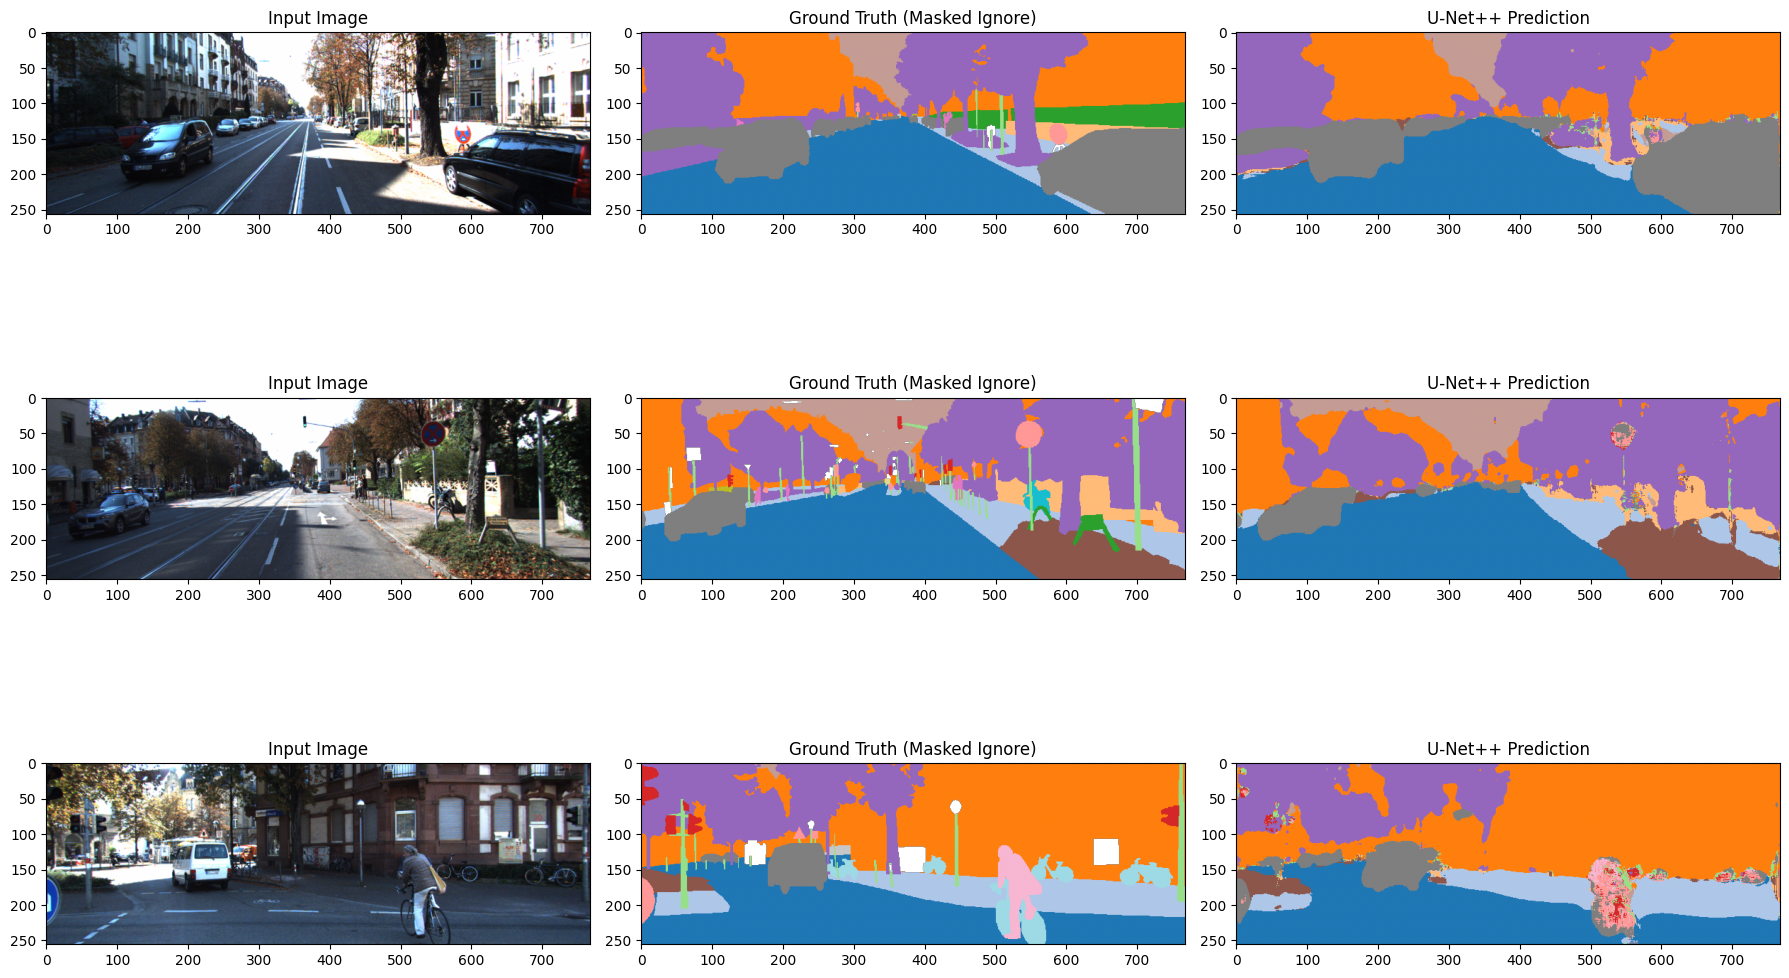

In [33]:
# 시각화 코드 수정: GT 마스크의 255(무시) 영역을 배경(0)과 구분하여 시각화
model_unet_plus.eval()
images, masks = next(iter(val_loader))
images_dev = images.to(device)

with torch.no_grad():
    pred_plus = torch.argmax(model_unet_plus(images_dev), dim=1).cpu().numpy()

num_samples = min(3, len(images))
fig, axes = plt.subplots(num_samples, 3, figsize=(18, 4 * num_samples))

for i in range(num_samples):
    img = images[i].permute(1, 2, 0).numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    gt_mask = masks[i].numpy()
    # 255(무시) 영역은 마스킹하여 투명하게 처리하거나 다른 색으로 표시
    gt_display = np.ma.masked_where(gt_mask == 255, gt_mask)

    axes[i, 0].imshow(img)
    axes[i, 0].set_title("Input Image")
    axes[i, 1].imshow(gt_display, cmap='tab20', vmin=0, vmax=18)
    axes[i, 1].set_title("Ground Truth (Masked Ignore)")
    axes[i, 2].imshow(pred_plus[i], cmap='tab20', vmin=0, vmax=18)
    axes[i, 2].set_title("U-Net++ Prediction")

plt.tight_layout()
plt.show()

### Ground Truth Mask 값 확인

`gt_mask`의 고유한 값들을 확인하여 왜 한 가지 색상으로 보이는지 이해해봅시다.

In [30]:
# KITTI 원본 마스크 파일의 실제 픽셀 값 직접 확인
import cv2
import numpy as np
import os

# 학습용 마스크 경로 설정
mask_sample_path = os.path.join(TRAIN_MASK_DIR, '000000_10.png')

if os.path.exists(mask_sample_path):
    raw_mask = cv2.imread(mask_sample_path, cv2.IMREAD_UNCHANGED)
    print(f"Raw mask shape: {raw_mask.shape}")
    print(f"Unique pixel values in raw mask: {np.unique(raw_mask)}")

    # 인코딩 후의 값 확인
    encoded_sample = encode_kitti_mask(raw_mask)
    print(f"Unique values after encode_kitti_mask: {np.unique(encoded_sample)}")

    if np.all(encoded_sample == 255):
        print("Warning: All pixels are mapped to 255! ID mapping table check required.")
else:
    print(f"File not found: {mask_sample_path}")

Raw mask shape: (375, 1242)
Unique pixel values in raw mask: [ 4  7  8 11 12 13 17 20 21 23 24 26 27 28]
Unique values after encode_kitti_mask: [  0   1   2   3   4   5   7   8  10  11  13  14  15 255]
